In [1]:
from google.colab import drive

drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import zipfile
from pathlib import Path
extract_path = Path("/content/extracted_data")

with zipfile.ZipFile('/content/drive/MyDrive/Deep_Learning/custumes/archive (23).zip', 'r') as ref:
    ref.extractall('extracted_data')

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/train',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

test_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/test',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.


In [4]:
import pandas as pd
import numpy as np

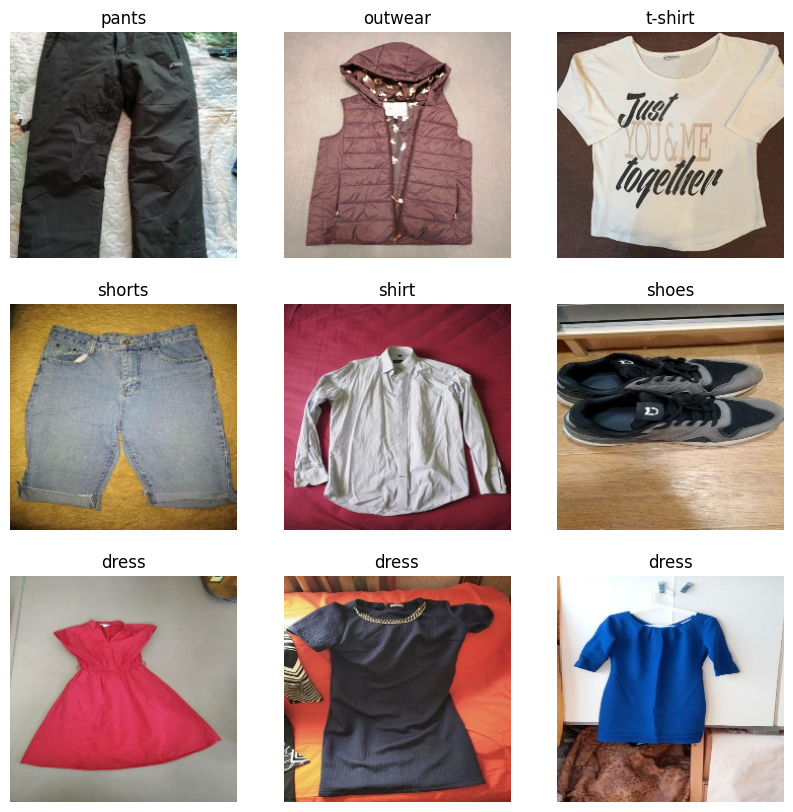

In [5]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names
plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(0,9):
        plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')





In [6]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

aug = Sequential([
    layers.RandomRotation(0.05, input_shape=(224,224,3),fill_mode='nearest'),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


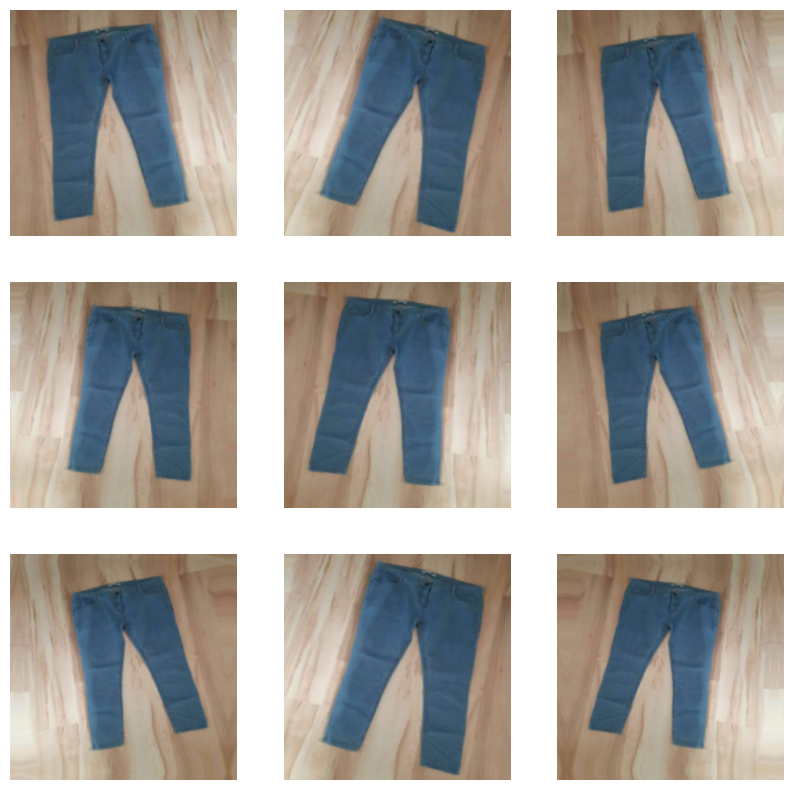

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,labels in train_ds.take(1):

    for i in range(9):
        agumented = aug(img)
        plt.subplot(3,3,i+1)
        plt.imshow(agumented[12].numpy().astype('uint8'))
        plt.axis('off')

In [11]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50V2(
    input_shape=(224,224,3),
    include_top = False,
    weights='imagenet')

base_model.trainable=False

In [28]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Dense, Dropout, Flatten, Lambda, Rescaling
from tensorflow.keras import Sequential

In [33]:
cnn = Sequential([
    aug,
    Rescaling(scale=2.0/255.0, offset=-1.0),
    # Lambda(lambda x: preprocess_input(x)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(10,activation='softmax'),
])

In [34]:
from tensorflow.keras.optimizers import Adam
ado = Adam(learning_rate=0.002)
closet_loss_function = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    name='sparse_categorical_crossentropy'
)


cnn.compile(optimizer=ado,loss=closet_loss_function,metrics=['accuracy'])

In [35]:
cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,530 (92.02 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [36]:
cnn.fit(train_ds,epochs=15,verbose=1,validation_data=test_ds)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - accuracy: 0.6538 - loss: 1.0507 - val_accuracy: 0.8065 - val_loss: 0.4826
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.7767 - loss: 0.6572 - val_accuracy: 0.8199 - val_loss: 0.5019
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.8113 - loss: 0.5552 - val_accuracy: 0.8710 - val_loss: 0.3818
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.8396 - loss: 0.4699 - val_accuracy: 0.8737 - val_loss: 0.3430
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.8553 - loss: 0.4096 - val_accuracy: 0.8548 - val_loss: 0.4223
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8608 - loss: 0.3936 - val_accuracy: 0.8925 - val_loss: 0.3288
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.8765 - loss: 0.3602 - val_accuracy: 0.9086 - val_loss: 0.2809
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.8915 - loss: 0.3012 - val_accu

In [38]:
cnn.save('cnn.keras')